In [ ]:
import pandas as pd
import numpy as np
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from pymongo import MongoClient
from pymongo.server_api import ServerApi


In [2]:
dep = pd.read_csv(r"C:\Users\johnb\OneDrive\Desktop\Employee Project\departments.csv")
dep


,DepartmentID,DepartmentName,Manager
0,D01,IT,John Smith
1,D02,Human Resources,Mary Johnson
2,D03,Finance,Peter Williams
3,D04,Sales,Sarah Miller
4,D05,Marketing,Linda Wilson
5,D02,HR,Mary Johnson (inconsistent naming)


In [3]:
emp = pd.read_csv(r"C:\Users\johnb\OneDrive\Desktop\Employee Project\employee.csv", encoding="latin1")
emp

#I got this error(UnicodeDecodeError: 'utf-8' codec can't decode byte 0xa0 in position 445: invalid start byte) pasted it on google and got the suggestion of using encoding="latin" which worked out.

,EmployeeID,FirstName,LastName,Gender,Age,DepartmentID,Salary,HireDate
0,1001,John,Smith,Male,32.0,D01,55000.0,5/10/2019
1,1002,Mary,Johnson,Female,28.0,D02,62000.0,7/15/2021
2,1003,Peter,Williams,Male,41.0,D03,78000.0,3/11/2018
3,1004,Grace,Brown,Female,35.0,D01,NaN,1/20/2020
4,1005,David,Jones,Male,NaN,D02,49000.0,2/15/2022
5,1006,Sarah,Miller,Female,45.0,D04,89000.0,9/12/2015
6,1007,Michael,Davis,Male,30.0,D01,54000.0,1/10/2023
7,1007,Michael,Davis,Male,30.0,D01,54000.0,2023-01-10
8,1008,Linda,Wilson,Female,27.0,D05,61000.0,11/8/2022
9,1009,James,Moore,Male,39.0,D03,72000.0,4/18/2017


In [4]:
perf = pd.read_csv(r"C:\Users\johnb\OneDrive\Desktop\Employee Project\performance.csv")
perf

,EmployeeID,PerformanceScore,Attendance,PromotionEligible
0,1001,92,98,Yes
1,1002,75,90,No
2,1003,88,96,Yes
3,1004,60,82,No
4,1005,55,78,No
5,1006,97,99,Yes
6,1007,81,93,Yes
7,1008,70,85,No
8,1009,89,95,Yes
9,1010,95,99,Yes


In [5]:
dep.head(5)


,DepartmentID,DepartmentName,Manager
0,D01,IT,John Smith
1,D02,Human Resources,Mary Johnson
2,D03,Finance,Peter Williams
3,D04,Sales,Sarah Miller
4,D05,Marketing,Linda Wilson


In [6]:
dep.tail(5)

,DepartmentID,DepartmentName,Manager
1,D02,Human Resources,Mary Johnson
2,D03,Finance,Peter Williams
3,D04,Sales,Sarah Miller
4,D05,Marketing,Linda Wilson
5,D02,HR,Mary Johnson (inconsistent naming)


In [7]:
emp.head(5)

,EmployeeID,FirstName,LastName,Gender,Age,DepartmentID,Salary,HireDate
0,1001,John,Smith,Male,32.0,D01,55000.0,5/10/2019
1,1002,Mary,Johnson,Female,28.0,D02,62000.0,7/15/2021
2,1003,Peter,Williams,Male,41.0,D03,78000.0,3/11/2018
3,1004,Grace,Brown,Female,35.0,D01,NaN,1/20/2020
4,1005,David,Jones,Male,NaN,D02,49000.0,2/15/2022


In [8]:
emp.tail(5)

,EmployeeID,FirstName,LastName,Gender,Age,DepartmentID,Salary,HireDate
10,1010,Patricia,Taylor,Female,50.0,D04,95000.0,8/1/2012
11,1011,Robert,Anderson,Male,29.0,D02,NaN,6/14/2021
12,1012,Jennifer,Thomas,Female,33.0,D05,67000.0,10/21/2019
13,1013,Daniel,Jackson,Male,38.0,D03,81000.0,5/30/2016
14,1014,Emily,White,Female,31.0,D01,59000.0,7/17/2020


In [9]:
perf.head(5)

,EmployeeID,PerformanceScore,Attendance,PromotionEligible
0,1001,92,98,Yes
1,1002,75,90,No
2,1003,88,96,Yes
3,1004,60,82,No
4,1005,55,78,No


In [10]:
perf.tail(5)

,EmployeeID,PerformanceScore,Attendance,PromotionEligible
9,1010,95,99,Yes
10,1011,68,84,No
11,1012,86,91,Yes
12,1013,90,94,No
13,1014,79,88,Yes


In [11]:
emp.shape

(15, 8)

In [12]:
perf.shape

(14, 4)

In [13]:
dep.shape

(6, 3)

In [14]:
dep.columns

Index(['DepartmentID', 'DepartmentName', 'Manager'], dtype='str')

In [15]:
emp.columns

Index(['EmployeeID', 'FirstName', 'LastName', 'Gender', 'Age', 'DepartmentID',
       'Salary', 'HireDate'],
      dtype='str')

In [16]:
perf.columns

Index(['EmployeeID', 'PerformanceScore', 'Attendance', 'PromotionEligible'], dtype='str')

In [17]:
emp.dtypes

EmployeeID        int64
FirstName           str
LastName            str
Gender              str
Age             float64
DepartmentID        str
Salary          float64
HireDate            str
dtype: object

In [18]:
perf.dtypes

EmployeeID           int64
PerformanceScore     int64
Attendance           int64
PromotionEligible      str
dtype: object

In [19]:
dep.dtypes

DepartmentID      str
DepartmentName    str
Manager           str
dtype: object

Part 2-- DATA CLEANING
Data Cleaning
Identify and fix:
duplicate employees
missing salaries
missing ages
inconsistent department names
leading/trailing spaces
incorrect data types
Explain every cleaning step.

In [20]:
dups = emp.duplicated().sum()
print(f"Exact duplicate rows: {dups}")

# Check for logicalduplicates (c duplicates (EmployeeID + FirstName)
logical_dups = emp.duplicated(subset=["EmployeeID","FirstName"]).sum()
print(f"Logical dup Employee + Firstname): {logical_dups}")	


Exact duplicate rows: 0
Logical dup Employee + Firstname): 1


In [21]:
dep1 = dep.copy()
dep1

,DepartmentID,DepartmentName,Manager
0,D01,IT,John Smith
1,D02,Human Resources,Mary Johnson
2,D03,Finance,Peter Williams
3,D04,Sales,Sarah Miller
4,D05,Marketing,Linda Wilson
5,D02,HR,Mary Johnson (inconsistent naming)


In [22]:
emp2= emp.copy()
emp2

,EmployeeID,FirstName,LastName,Gender,Age,DepartmentID,Salary,HireDate
0,1001,John,Smith,Male,32.0,D01,55000.0,5/10/2019
1,1002,Mary,Johnson,Female,28.0,D02,62000.0,7/15/2021
2,1003,Peter,Williams,Male,41.0,D03,78000.0,3/11/2018
3,1004,Grace,Brown,Female,35.0,D01,NaN,1/20/2020
4,1005,David,Jones,Male,NaN,D02,49000.0,2/15/2022
5,1006,Sarah,Miller,Female,45.0,D04,89000.0,9/12/2015
6,1007,Michael,Davis,Male,30.0,D01,54000.0,1/10/2023
7,1007,Michael,Davis,Male,30.0,D01,54000.0,2023-01-10
8,1008,Linda,Wilson,Female,27.0,D05,61000.0,11/8/2022
9,1009,James,Moore,Male,39.0,D03,72000.0,4/18/2017


In [23]:

#Remove duplicates based on a "EmployeeID" column from Emp1 Dataframe , keeping the first occurrence
emp2_no_duplicates_id = emp2.drop_duplicates(subset=["EmployeeID"], keep="first", inplace=True)
print(f"Duplicates removed from Employee list (Based on ID, keep first)")

#Replace missing Salary- Replace NaN with (-)
emp2["Salary"] = emp2["Salary"].replace(np.nan, "0")
print("Replaced Nan with 0 for missing Salary")


#Replace missing Age- Replace Nan with (-)
emp2["Age"] = emp2["Age"].replace(np.nan,"0")
print("Replaced Nan with 0 for missing Age")

print(f"Clean dataset shape: {emp2.shape}")
emp2


Duplicates removed from Employee list (Based on ID, keep first)
Replaced Nan with 0 for missing Salary
Replaced Nan with 0 for missing Age
Clean dataset shape: (14, 8)


,EmployeeID,FirstName,LastName,Gender,Age,DepartmentID,Salary,HireDate
0,1001,John,Smith,Male,32.0,D01,55000.0,5/10/2019
1,1002,Mary,Johnson,Female,28.0,D02,62000.0,7/15/2021
2,1003,Peter,Williams,Male,41.0,D03,78000.0,3/11/2018
3,1004,Grace,Brown,Female,35.0,D01,0,1/20/2020
4,1005,David,Jones,Male,0,D02,49000.0,2/15/2022
5,1006,Sarah,Miller,Female,45.0,D04,89000.0,9/12/2015
6,1007,Michael,Davis,Male,30.0,D01,54000.0,1/10/2023
8,1008,Linda,Wilson,Female,27.0,D05,61000.0,11/8/2022
9,1009,James,Moore,Male,39.0,D03,72000.0,4/18/2017
10,1010,Patricia,Taylor,Female,50.0,D04,95000.0,8/1/2012


In [24]:
emp2["Age"]= emp2["Age"].astype("int64")
emp2["Salary"]= emp2["Salary"].astype("int64")




In [25]:
emp2.info()

<class 'pandas.DataFrame'>
Index: 14 entries, 0 to 14
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   EmployeeID    14 non-null     int64
 1   FirstName     14 non-null     str  
 2   LastName      14 non-null     str  
 3   Gender        14 non-null     str  
 4   Age           14 non-null     int64
 5   DepartmentID  14 non-null     str  
 6   Salary        14 non-null     int64
 7   HireDate      14 non-null     str  
dtypes: int64(3), str(5)
memory usage: 1008.0 bytes


In [26]:
emp2.to_csv(r"C:\Users\johnb\OneDrive\Desktop\Employee Project\employees_clean.csv", index=False)


In [27]:
#Remove duplicates based on a "DepartmentID" column from Department Dataframe , keeping the first occurrence
dep1_no_duplicates_id = dep1.drop_duplicates(subset=["DepartmentID"], keep="first", inplace=True)
print(f"Duplicates removed from Department list (Based on ID, keep first)")

print(f"Clean dataset shape: {dep1.shape}")
dep1

Duplicates removed from Department list (Based on ID, keep first)
Clean dataset shape: (5, 3)


,DepartmentID,DepartmentName,Manager
0,D01,IT,John Smith
1,D02,Human Resources,Mary Johnson
2,D03,Finance,Peter Williams
3,D04,Sales,Sarah Miller
4,D05,Marketing,Linda Wilson


In [28]:
dep1.to_csv(r"C:\Users\johnb\OneDrive\Desktop\Employee Project\department_clean.csv", index=False)


Part 3
Data Integration
Merge all three datasets into one master DataFrame.
Display:
first ten rows
shape
missing values after merging

In [29]:
emp2.shape, dep1.shape, perf.shape


((14, 8), (5, 3), (14, 4))

In [30]:

# When columns have different names across files
master_df = emp2.merge(perf, left_on= "EmployeeID", right_on= "EmployeeID", how="left")
master_df1 = master_df.merge(dep1, left_on= "DepartmentID", right_on= "DepartmentID", how="left")
master_df1




,EmployeeID,FirstName,LastName,Gender,Age,DepartmentID,Salary,HireDate,PerformanceScore,Attendance,PromotionEligible,DepartmentName,Manager
0,1001,John,Smith,Male,32,D01,55000,5/10/2019,92,98,Yes,IT,John Smith
1,1002,Mary,Johnson,Female,28,D02,62000,7/15/2021,75,90,No,Human Resources,Mary Johnson
2,1003,Peter,Williams,Male,41,D03,78000,3/11/2018,88,96,Yes,Finance,Peter Williams
3,1004,Grace,Brown,Female,35,D01,0,1/20/2020,60,82,No,IT,John Smith
4,1005,David,Jones,Male,0,D02,49000,2/15/2022,55,78,No,Human Resources,Mary Johnson
5,1006,Sarah,Miller,Female,45,D04,89000,9/12/2015,97,99,Yes,Sales,Sarah Miller
6,1007,Michael,Davis,Male,30,D01,54000,1/10/2023,81,93,Yes,IT,John Smith
7,1008,Linda,Wilson,Female,27,D05,61000,11/8/2022,70,85,No,Marketing,Linda Wilson
8,1009,James,Moore,Male,39,D03,72000,4/18/2017,89,95,Yes,Finance,Peter Williams
9,1010,Patricia,Taylor,Female,50,D04,95000,8/1/2012,95,99,Yes,Sales,Sarah Miller


In [31]:
master_df1.head(10)

,EmployeeID,FirstName,LastName,Gender,Age,DepartmentID,Salary,HireDate,PerformanceScore,Attendance,PromotionEligible,DepartmentName,Manager
0,1001,John,Smith,Male,32,D01,55000,5/10/2019,92,98,Yes,IT,John Smith
1,1002,Mary,Johnson,Female,28,D02,62000,7/15/2021,75,90,No,Human Resources,Mary Johnson
2,1003,Peter,Williams,Male,41,D03,78000,3/11/2018,88,96,Yes,Finance,Peter Williams
3,1004,Grace,Brown,Female,35,D01,0,1/20/2020,60,82,No,IT,John Smith
4,1005,David,Jones,Male,0,D02,49000,2/15/2022,55,78,No,Human Resources,Mary Johnson
5,1006,Sarah,Miller,Female,45,D04,89000,9/12/2015,97,99,Yes,Sales,Sarah Miller
6,1007,Michael,Davis,Male,30,D01,54000,1/10/2023,81,93,Yes,IT,John Smith
7,1008,Linda,Wilson,Female,27,D05,61000,11/8/2022,70,85,No,Marketing,Linda Wilson
8,1009,James,Moore,Male,39,D03,72000,4/18/2017,89,95,Yes,Finance,Peter Williams
9,1010,Patricia,Taylor,Female,50,D04,95000,8/1/2012,95,99,Yes,Sales,Sarah Miller


In [32]:
print(f"Shape : {master_df1.shape}")
print(f" No missing value after merging")


Shape : (14, 13)
 No missing value after merging


In [33]:
master_df1.to_csv(r"C:\Users\johnb\OneDrive\Desktop\Employee Project\merged_employee_data.csv", index=False)


4. Data Analysis 
Answer the following business questions.
How many employees does the company have?
Which department has the highest number of employees?
Which department has the highest average salary?
Who earns the highest salary?
Calculate the average salary.
How many male and female employees are there?
Which employees are eligible for promotion?
Which department has the best attendance?
Display employees earning above the company average.
Which employees have excellent performance but are not eligible for promotion?

In [34]:

employeeid = master_df1["EmployeeID"]
employeeid
count = len(employeeid)
print(f"Number of Employee: {count}")



Number of Employee: 14


In [35]:
#Who earns the highest salary
master_df1[master_df1["Salary"] == max(master_df1["Salary"])]

,EmployeeID,FirstName,LastName,Gender,Age,DepartmentID,Salary,HireDate,PerformanceScore,Attendance,PromotionEligible,DepartmentName,Manager
9,1010,Patricia,Taylor,Female,50,D04,95000,8/1/2012,95,99,Yes,Sales,Sarah Miller


In [36]:
#Average Salary
emp_salary = master_df1["Salary"]
mean = sum(emp_salary) / len(emp_salary)
print(mean)

58714.28571428572


In [37]:
#Which department has the highest average salary?
avg_sal = master_df1[master_df1["Salary"] >= 58714]
avg_dept = avg_sal["DepartmentName"]
count_avg_dept = Counter(avg_dept)
print(count_avg_dept)

dept_highest_avgsal= max(count_avg_dept, key=count_avg_dept.get)
print(dept_highest_avgsal)

Counter({'Finance': 3, 'Sales': 2, 'Marketing': 2, 'Human Resources': 1, 'IT': 1})
Finance


In [38]:
#Which department has the highest number of employees?
dept = master_df1["DepartmentName"]
count_dept = Counter(dept)
print(count_dept)

dept_highest_emp = max(count_dept, key=count_dept.get)
print(dept_highest_emp)



Counter({'IT': 4, 'Human Resources': 3, 'Finance': 3, 'Sales': 2, 'Marketing': 2})
IT


In [39]:
#How many male and female employees are there?

gen = master_df1["Gender"]
count_gen = Counter(gen)
print(count_gen)

Counter({'Male': 7, 'Female': 7})


In [40]:
# Which employees are eligible for promotion?


master_df1[master_df1["PromotionEligible"] == "Yes"]

,EmployeeID,FirstName,LastName,Gender,Age,DepartmentID,Salary,HireDate,PerformanceScore,Attendance,PromotionEligible,DepartmentName,Manager
0,1001,John,Smith,Male,32,D01,55000,5/10/2019,92,98,Yes,IT,John Smith
2,1003,Peter,Williams,Male,41,D03,78000,3/11/2018,88,96,Yes,Finance,Peter Williams
5,1006,Sarah,Miller,Female,45,D04,89000,9/12/2015,97,99,Yes,Sales,Sarah Miller
6,1007,Michael,Davis,Male,30,D01,54000,1/10/2023,81,93,Yes,IT,John Smith
8,1009,James,Moore,Male,39,D03,72000,4/18/2017,89,95,Yes,Finance,Peter Williams
9,1010,Patricia,Taylor,Female,50,D04,95000,8/1/2012,95,99,Yes,Sales,Sarah Miller
11,1012,Jennifer,Thomas,Female,33,D05,67000,10/21/2019,86,91,Yes,Marketing,Linda Wilson
13,1014,Emily,White,Female,31,D01,59000,7/17/2020,79,88,Yes,IT,John Smith


In [41]:
# Which department has the best attendance?
master_df1[master_df1["Attendance"] == max(master_df1["Attendance"])]

,EmployeeID,FirstName,LastName,Gender,Age,DepartmentID,Salary,HireDate,PerformanceScore,Attendance,PromotionEligible,DepartmentName,Manager
5,1006,Sarah,Miller,Female,45,D04,89000,9/12/2015,97,99,Yes,Sales,Sarah Miller
9,1010,Patricia,Taylor,Female,50,D04,95000,8/1/2012,95,99,Yes,Sales,Sarah Miller


In [42]:
#Display employees earning above the company average.
master_df1[master_df1["Salary"] >= 58714]

,EmployeeID,FirstName,LastName,Gender,Age,DepartmentID,Salary,HireDate,PerformanceScore,Attendance,PromotionEligible,DepartmentName,Manager
1,1002,Mary,Johnson,Female,28,D02,62000,7/15/2021,75,90,No,Human Resources,Mary Johnson
2,1003,Peter,Williams,Male,41,D03,78000,3/11/2018,88,96,Yes,Finance,Peter Williams
5,1006,Sarah,Miller,Female,45,D04,89000,9/12/2015,97,99,Yes,Sales,Sarah Miller
7,1008,Linda,Wilson,Female,27,D05,61000,11/8/2022,70,85,No,Marketing,Linda Wilson
8,1009,James,Moore,Male,39,D03,72000,4/18/2017,89,95,Yes,Finance,Peter Williams
9,1010,Patricia,Taylor,Female,50,D04,95000,8/1/2012,95,99,Yes,Sales,Sarah Miller
11,1012,Jennifer,Thomas,Female,33,D05,67000,10/21/2019,86,91,Yes,Marketing,Linda Wilson
12,1013,Daniel,Jackson,Male,38,D03,81000,5/30/2016,90,94,No,Finance,Peter Williams
13,1014,Emily,White,Female,31,D01,59000,7/17/2020,79,88,Yes,IT,John Smith


In [69]:
p = master_df1.groupby("DepartmentName").size()
p

DepartmentName
Finance            3
Human Resources    3
IT                 4
Marketing          2
Sales              2
dtype: int64

In [43]:
#Which employees have excellent performance but are not eligible for promotion?

p_elig = master_df1[master_df1["PromotionEligible"] == "No"]
# p_elig
p_elig[p_elig["PerformanceScore"] >= 90]

,EmployeeID,FirstName,LastName,Gender,Age,DepartmentID,Salary,HireDate,PerformanceScore,Attendance,PromotionEligible,DepartmentName,Manager
12,1013,Daniel,Jackson,Male,38,D03,81000,5/30/2016,90,94,No,Finance,Peter Williams


Part 5
Visualization
Create the following charts.
Employees per department
Average salary by department
Gender distribution
Performance score distribution
Save all charts.

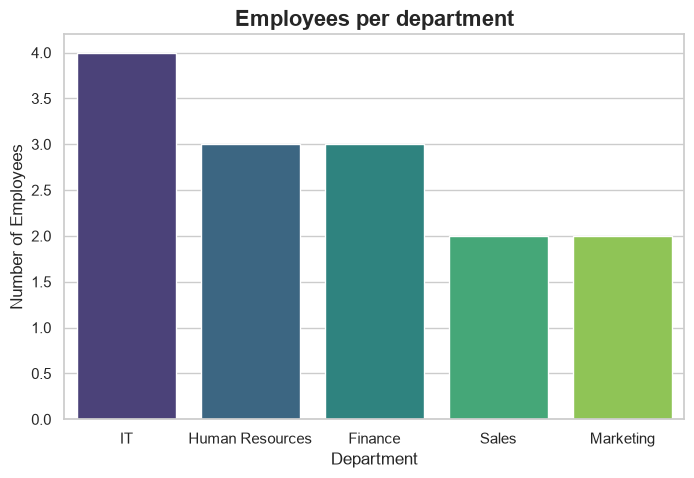

In [44]:
#Employees per department
# 1. Set a beautiful visual style using Seaborn
sns.set_theme(style="whitegrid")

# 2. Define some sample data

department = ["IT", "Human Resources", "Finance", "Sales", "Marketing"]
number = [4, 3, 3, 2, 2]

# 3. Create the static plot
plt.figure(figsize=(8, 5))
# sns.barplot(x=department, y=number, palette="viridis")
sns.barplot(x=department, y=number, hue=department, palette="viridis", legend=False)


# 4. Customize labels and titles
plt.title("Employees per department", fontsize=16, fontweight="bold")
plt.xlabel("Department", fontsize=12)
plt.ylabel("Number of Employees", fontsize=12)

# 5. Save the chart as a high-quality image file
plt.savefig("employee per dept.png", dpi=300, bbox_inches="tight")

# 6. Display the chart on your screen
plt.show()


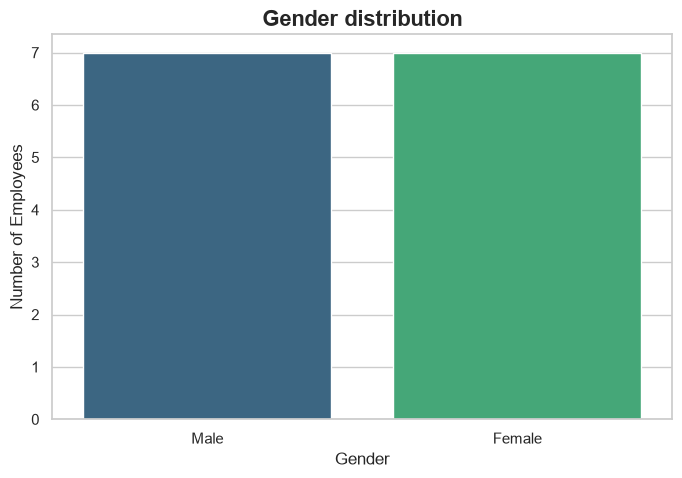

In [45]:
#Gender distribution
# 1. Set a beautiful visual style using Seaborn
sns.set_theme(style="whitegrid")

# 2. Define some sample data

gender = ["Male", "Female"]
number = [7, 7]

# 3. Create the static plot
plt.figure(figsize=(8, 5))
sns.barplot(x=gender, y=number, hue=gender, palette="viridis", legend=False)


# 4. Customize labels and titles
plt.title("Gender distribution", fontsize=16, fontweight="bold")
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Number of Employees", fontsize=12)

# 5. Save the chart as a high-quality image file
plt.savefig("Gender distribution.png", dpi=300, bbox_inches="tight")

# 6. Display the chart on your screen
plt.show()


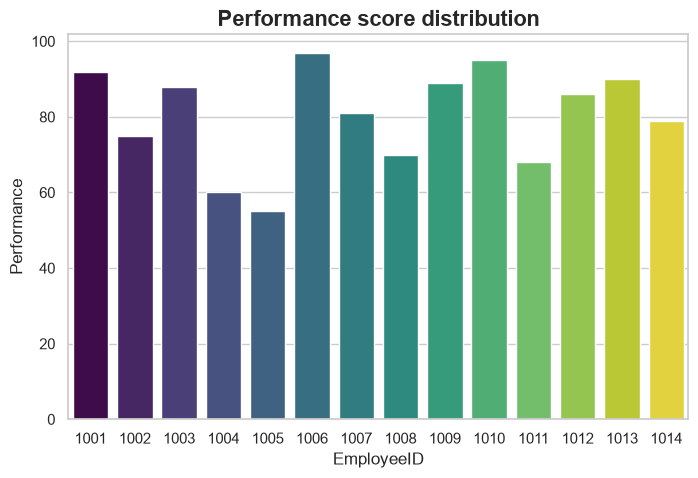

In [46]:
#Performance score distribution

# 1. Set a beautiful visual style using Seaborn
sns.set_theme(style="whitegrid")

# 2. Define some sample data

employeeId = master_df1["EmployeeID"]
performanceScore = master_df1["PerformanceScore"]

# 3. Create the static plot
plt.figure(figsize=(8, 5))
sns.barplot(x=employeeId, y=performanceScore, hue=employeeId, palette="viridis", legend=False)


# 4. Customize labels and titles
plt.title("Performance score distribution", fontsize=16, fontweight="bold")
plt.xlabel("EmployeeID", fontsize=12)
plt.ylabel("Performance", fontsize=12)

# 5. Save the chart as a high-quality image file
plt.savefig("Performance score distribution.png", dpi=300, bbox_inches="tight")

# 6. Display the chart on your screen
plt.show()

Part 6
MongoDB Create Database EmployeeDB, Collection Employees

- Insert all cleaned records.

Write queries to retrieve:
- all IT employees
- employees earning above 80,000
- employees eligible for promotion

In [47]:
uri = "mongodb://localhost:27017/"

# Create a new client and connect to the server
client = MongoClient(uri, server_api=ServerApi('1'))

# Send a ping to confirm a successful connection
try:
    client.admin.command('ping')
    print("Pinged your deployment. You successfully connected to MongoDB!")
    # for i in client.list_database_names():
    #     print (i)
except Exception as e:
    print(e)

Pinged your deployment. You successfully connected to MongoDB!


In [48]:
database = client["EmployeeDB"]
collection = database["Employees"]
# print(collection)

# records_to_insert = master_df1.to_dict("records")
# rec = collection.insert_many(records_to_insert)
# # print(rec)



In [49]:
it_team = collection.find({"DepartmentName": "IT"})
for document in it_team:
    print(document)


{'_id': ObjectId('6a55641411e03138a548a3eb'), 'EmployeeID': 1001, 'FirstName': 'John', 'LastName': 'Smith', 'Gender': 'Male', 'Age': 32, 'DepartmentID': 'D01', 'Salary': 55000, 'HireDate': '5/10/2019', 'PerformanceScore': 92, 'Attendance': 98, 'PromotionEligible': 'Yes', 'DepartmentName': 'IT', 'Manager': 'John Smith'}
{'_id': ObjectId('6a55641411e03138a548a3ee'), 'EmployeeID': 1004, 'FirstName': 'Grace', 'LastName': 'Brown', 'Gender': 'Female', 'Age': 35, 'DepartmentID': 'D01', 'Salary': 0, 'HireDate': '1/20/2020', 'PerformanceScore': 60, 'Attendance': 82, 'PromotionEligible': 'No', 'DepartmentName': 'IT', 'Manager': 'John Smith'}
{'_id': ObjectId('6a55641411e03138a548a3f1'), 'EmployeeID': 1007, 'FirstName': 'Michael', 'LastName': 'Davis', 'Gender': 'Male', 'Age': 30, 'DepartmentID': 'D01', 'Salary': 54000, 'HireDate': '1/10/2023', 'PerformanceScore': 81, 'Attendance': 93, 'PromotionEligible': 'Yes', 'DepartmentName': 'IT', 'Manager': 'John Smith'}
{'_id': ObjectId('6a55641411e03138a5

In [50]:
sal = {"Salary": {"$gte": 80000}}
sal_above = collection.find(sal)
for i in sal_above:
    print(i)

{'_id': ObjectId('6a55641411e03138a548a3f0'), 'EmployeeID': 1006, 'FirstName': 'Sarah', 'LastName': 'Miller', 'Gender': 'Female', 'Age': 45, 'DepartmentID': 'D04', 'Salary': 89000, 'HireDate': '9/12/2015', 'PerformanceScore': 97, 'Attendance': 99, 'PromotionEligible': 'Yes', 'DepartmentName': 'Sales', 'Manager': 'Sarah Miller'}
{'_id': ObjectId('6a55641411e03138a548a3f4'), 'EmployeeID': 1010, 'FirstName': 'Patricia', 'LastName': 'Taylor', 'Gender': 'Female', 'Age': 50, 'DepartmentID': 'D04', 'Salary': 95000, 'HireDate': '8/1/2012', 'PerformanceScore': 95, 'Attendance': 99, 'PromotionEligible': 'Yes', 'DepartmentName': 'Sales', 'Manager': 'Sarah Miller'}
{'_id': ObjectId('6a55641411e03138a548a3f7'), 'EmployeeID': 1013, 'FirstName': 'Daniel', 'LastName': 'Jackson', 'Gender': 'Male', 'Age': 38, 'DepartmentID': 'D03', 'Salary': 81000, 'HireDate': '5/30/2016', 'PerformanceScore': 90, 'Attendance': 94, 'PromotionEligible': 'No', 'DepartmentName': 'Finance', 'Manager': 'Peter Williams'}


In [51]:
eligible_employee_for_promotion = collection.find({"PromotionEligible": "Yes"})
for document in eligible_employee_for_promotion:
    print(document)

{'_id': ObjectId('6a55641411e03138a548a3eb'), 'EmployeeID': 1001, 'FirstName': 'John', 'LastName': 'Smith', 'Gender': 'Male', 'Age': 32, 'DepartmentID': 'D01', 'Salary': 55000, 'HireDate': '5/10/2019', 'PerformanceScore': 92, 'Attendance': 98, 'PromotionEligible': 'Yes', 'DepartmentName': 'IT', 'Manager': 'John Smith'}
{'_id': ObjectId('6a55641411e03138a548a3ed'), 'EmployeeID': 1003, 'FirstName': 'Peter', 'LastName': 'Williams', 'Gender': 'Male', 'Age': 41, 'DepartmentID': 'D03', 'Salary': 78000, 'HireDate': '3/11/2018', 'PerformanceScore': 88, 'Attendance': 96, 'PromotionEligible': 'Yes', 'DepartmentName': 'Finance', 'Manager': 'Peter Williams'}
{'_id': ObjectId('6a55641411e03138a548a3f0'), 'EmployeeID': 1006, 'FirstName': 'Sarah', 'LastName': 'Miller', 'Gender': 'Female', 'Age': 45, 'DepartmentID': 'D04', 'Salary': 89000, 'HireDate': '9/12/2015', 'PerformanceScore': 97, 'Attendance': 99, 'PromotionEligible': 'Yes', 'DepartmentName': 'Sales', 'Manager': 'Sarah Miller'}
{'_id': ObjectI

In [52]:
client.close()


Part 7
SQL 
Write SQL queries to answer:
Display all employees.
Find employees older than 40.
Calculate average salary.
Count employees per department.
Find employees earning above average salary.

In [ ]:
Data Source=localhost\SQLEXPRESS;Initial Catalog=master;Integrated Security=True;Persist Security Info=False;Pooling=False;MultipleActiveResultSets=False;Encrypt=True;TrustServerCertificate=True;Command Timeout=0

In [53]:
master_to_dict = master_df1.to_dict(orient='records')
master_to_dict

[{'EmployeeID': 1001,
  'FirstName': 'John',
  'LastName': 'Smith',
  'Gender': 'Male',
  'Age': 32,
  'DepartmentID': 'D01',
  'Salary': 55000,
  'HireDate': '5/10/2019',
  'PerformanceScore': 92,
  'Attendance': 98,
  'PromotionEligible': 'Yes',
  'DepartmentName': 'IT',
  'Manager': 'John Smith'},
 {'EmployeeID': 1002,
  'FirstName': 'Mary',
  'LastName': 'Johnson',
  'Gender': 'Female',
  'Age': 28,
  'DepartmentID': 'D02',
  'Salary': 62000,
  'HireDate': '7/15/2021',
  'PerformanceScore': 75,
  'Attendance': 90,
  'PromotionEligible': 'No',
  'DepartmentName': 'Human Resources',
  'Manager': 'Mary Johnson'},
 {'EmployeeID': 1003,
  'FirstName': 'Peter',
  'LastName': 'Williams',
  'Gender': 'Male',
  'Age': 41,
  'DepartmentID': 'D03',
  'Salary': 78000,
  'HireDate': '3/11/2018',
  'PerformanceScore': 88,
  'Attendance': 96,
  'PromotionEligible': 'Yes',
  'DepartmentName': 'Finance',
  'Manager': 'Peter Williams'},
 {'EmployeeID': 1004,
  'FirstName': 'Grace',
  'LastName': 'Br

In [14]:
import pandas as pd
from sqlalchemy import create_engine, text
# 1. Define your server parameters
SERVER = "localhost\SQLEXPRESS"  # e.g., 'localhost' or 'YOUR-PC\SQLEXPRESS'
NEW_DB = "EmployeeDatabase"
TABLE_NAME = "EmployeeMasterTable"
# Create a sample DataFrame to save
data = master_to_dict
df = pd.DataFrame(data)
# 2. Connect to the master database to create the new database
# # (SQL Server requires autocommit=True to execute CREATE DATABASE)
master_url = f"mssql+pyodbc://@{SERVER}/master?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes"
engine_master = create_engine(master_url, connect_args={"autocommit": True})

print(f"Creating database '{NEW_DB}'...")
with engine_master.connect() as conn:
    # Check if database exists, if not, create it    
    conn.execute(
        text(
            f"IF NOT EXISTS (SELECT * FROM sys.databases WHERE name = '{NEW_DB}') CREATE DATABASE {NEW_DB}"        )
    )
# 3. Create a new engine connected directly to your new database
db_url = f"mssql+pyodbc://@{SERVER}/{NEW_DB}?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes"
engine_db = create_engine(db_url)
# 4. Save the DataFrame into the new database
print(f"Saving DataFrame to table '{TABLE_NAME}'...")
df.to_sql(
    name=TABLE_NAME,
    con=engine_db,
    if_exists="replace",  # Options: 'fail', 'replace', 'append'   
    index=False,  # Set to True if you want the DataFrame index as a column)
)
print("Done! Data successfully saved.")

<>:4: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<>:4: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
C:\Users\johnb\AppData\Local\Temp\ipykernel_4552\2689053836.py:4: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
  SERVER = "localhost\SQLEXPRESS"  # e.g., 'localhost' or 'YOUR-PC\SQLEXPRESS'


Creating database 'EmployeeDatabase'...
Saving DataFrame to table 'MasterTable'...
Done! Data successfully saved.


In [54]:
import pandas as pd
from sqlalchemy import create_engine, text
# 1. Define your server parameters
SERVER = "localhost\SQLEXPRESS"  # e.g., 'localhost' or 'YOUR-PC\SQLEXPRESS'
NEW_DB = "EmployeeDatabase"
TABLE_NAME = "EmployeeMasterTable"
# Create a sample DataFrame to save
data = master_to_dict
df = pd.DataFrame(data)
# 2. Connect to the master database to create the new database
# # (SQL Server requires autocommit=True to execute CREATE DATABASE)
master_url = f"mssql+pyodbc://@{SERVER}/master?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes"
engine_master = create_engine(master_url, connect_args={"autocommit": True})

print(f"Creating database '{NEW_DB}'...")
with engine_master.connect() as conn:
    # Check if database exists, if not, create it    
    conn.execute(
        text(
            f"IF NOT EXISTS (SELECT * FROM sys.databases WHERE name = '{NEW_DB}') CREATE DATABASE {NEW_DB}"        )
    )
# 3. Create a new engine connected directly to your new database
db_url = f"mssql+pyodbc://@{SERVER}/{NEW_DB}?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes"
engine_db = create_engine(db_url)
# 4. Save the DataFrame into the new database
print(f"Saving DataFrame to table '{TABLE_NAME}'...")
df.to_sql(
    name=TABLE_NAME,
    con=engine_db,
    if_exists="replace",  # Options: 'fail', 'replace', 'append'   
    index=False,  # Set to True if you want the DataFrame index as a column)
)
print("Done! Data successfully saved.")

<>:4: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<>:4: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
C:\Users\johnb\AppData\Local\Temp\ipykernel_17848\1782224771.py:4: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
  SERVER = "localhost\SQLEXPRESS"  # e.g., 'localhost' or 'YOUR-PC\SQLEXPRESS'


Creating database 'EmployeeDatabase'...
Saving DataFrame to table 'EmployeeMasterTable'...
Done! Data successfully saved.
